$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 3.3

在实际研究中，无法在开展实验前预先获知尺度参数的取值。因此，探究该参数是否会对最优试验设计产生影响具有重要意义。图 3.3 上方子图绘制了积分均方误差（IMSE）与最小最大均方误差（MMSE）的数值曲线。可以看出两类误差数值随 $\theta$ 变化显著。当 $\theta$ 取值极小或极大时，各类试验设计的表现趋于一致。该现象可以合理解释：$\theta$ 取值较小时，响应曲面起伏剧烈，全部 10 组试验设计均难以精准拟合该响应曲面；与之类似，$\theta$ 取值较大时，响应曲面平缓光滑，所有试验设计均可较好地完成曲面拟合。只有当 $\theta$ 处于中间区间时，不同试验设计的性能才会出现明显差异。可定义相对效率用以区分不同试验设计的优劣，对应公式如下：

相对积分均方效率：

$$
RE_I(D_i; \boldsymbol{\theta})=
\frac{\min_i \text{IMSE}(D_i; \boldsymbol{\theta})}
{\text{IMSE}(D_i; \boldsymbol{\theta})}
$$

相对最小最大均方效率：

$$
RE_M(D_i; \boldsymbol{\theta})=
\frac{\min_i \text{MMSE}(D_i; \boldsymbol{\theta})}
{\text{MMSE}(D_i; \boldsymbol{\theta})}
$$

其中 $i=1,2,3,4$。

四种设计方案在积分均方误差（IMSE）与最小均方误差（MMSE）指标下的相对效率绘制于图 3.3 下方子图中。可以看出，最优设计方案会随着参数 $\theta$ 取值的变化而改变。例如，当 $\theta < 0.3$ 时，切比雪夫设计在积分均方误差指标下表现很差，但当 $\theta > 0.3$ 时该设计性能最优。这一结果对我们的最优设计方案而言是不利的。不过仍存在可行思路：等间隔设计与最小均方误差最优设计即便无法在任意 $\theta$ 取值下达到最优，但其在全部 $\theta$ 取值范围内的表现都较为稳定。因此，我们需要求解对参数 $\theta$ 具备鲁棒性的设计方案，该优化问题可表示为：

$$
\max_{D}\min_{\boldsymbol{\theta}\in\Theta}\frac{\text{IMSE}(D^*(\boldsymbol{\theta}); \boldsymbol{\theta})}{\text{IMSE}(D; \boldsymbol{\theta})}
$$

其中

$$
D^*(\boldsymbol{\theta}) = \argmin_{\boldsymbol{\theta}\in\Theta}\text{IMSE}(D; \boldsymbol{\theta})
$$

且 $\Theta \subset[0, +\infty)^p$。鲁棒最小均方误差最优设计可按照相同方式定义。

由图 3.3 可见，当 $\theta$ 趋近于 0（即相关性趋近于 0）时，所有设计方案的表现均较差，该情形对应变量近似相互独立。在此条件下，矩阵 $\boldsymbol{R}$ 趋近于单位矩阵 $\boldsymbol{I}$，因此无需对矩阵 $\boldsymbol{R}$ 求逆即可计算集成均方误差（IMSE）准则与最小均方误差（MMSE）准则，能够大幅降低计算量。此外，在该极限条件下求得的各类设计方案，在相关性较强的场景中同样具备不错的效果。这类设计被称作填充设计，不仅构造难度更低，还能够抵御相关结构设定错误带来的影响，具备稳健性。因此我们将填充设计作为计算机试验的初始设计。

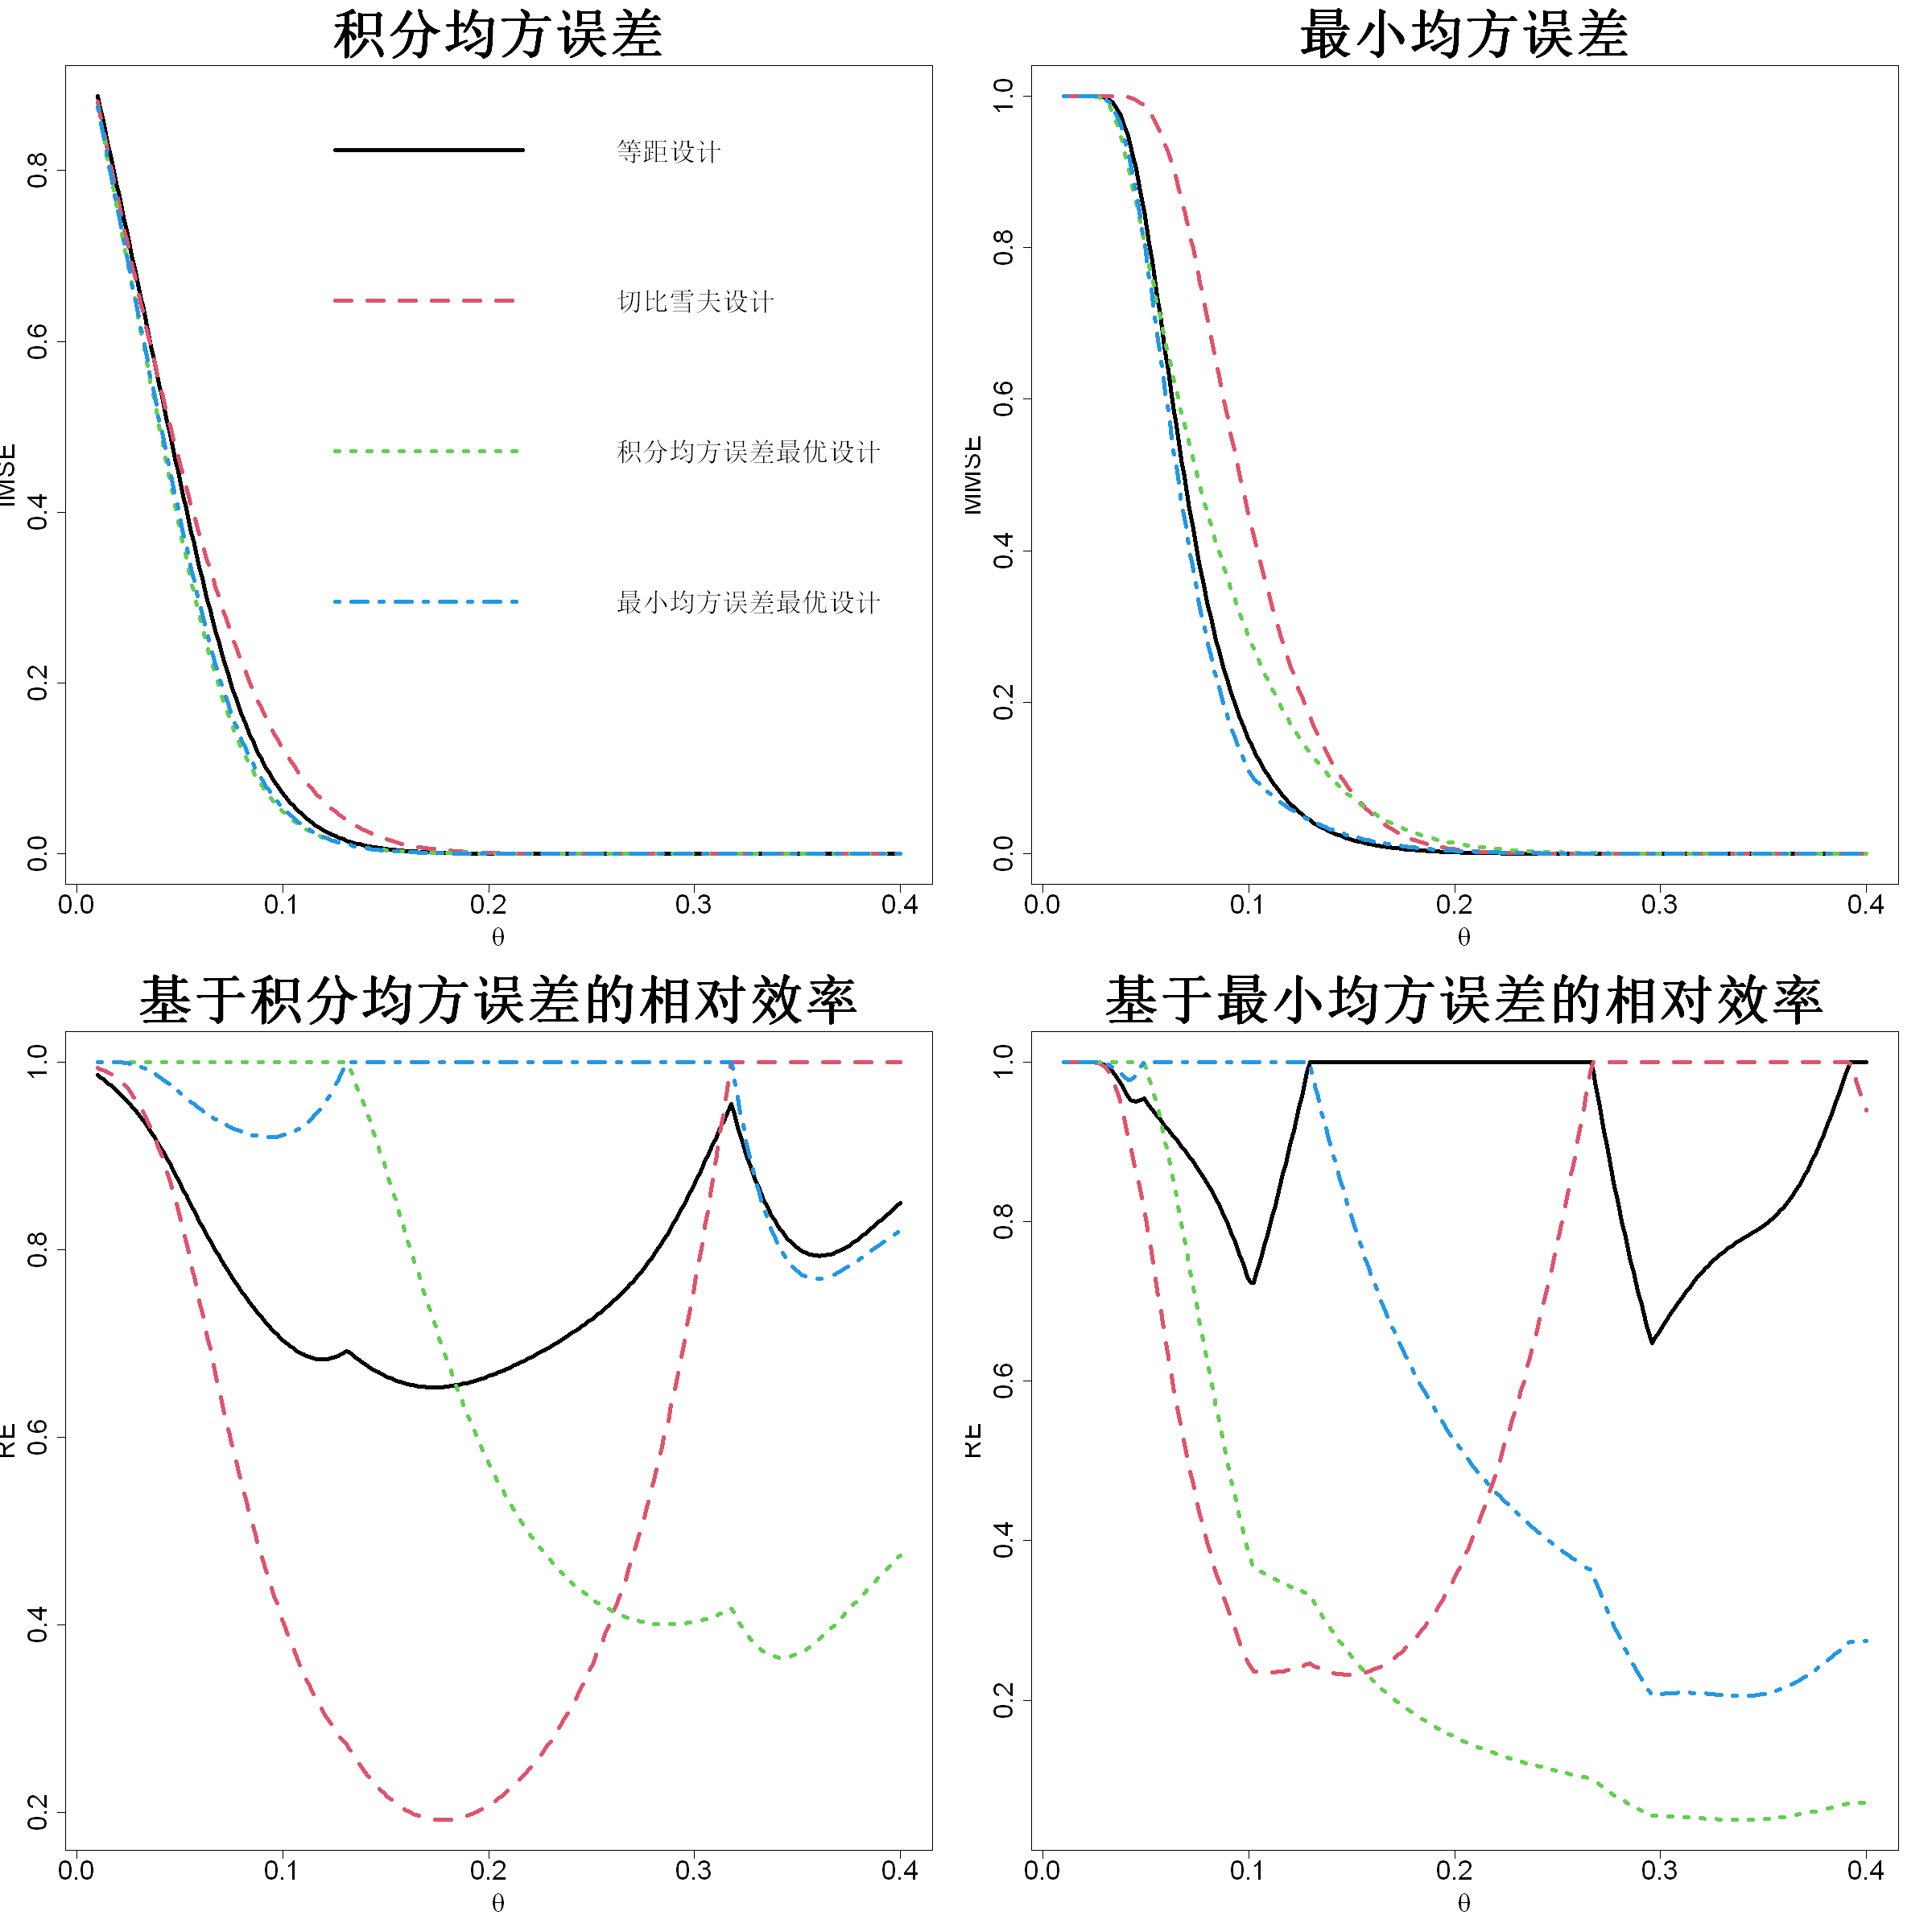

In [6]:
if(!dir.exists("data"))dir.create("data")
if(!file.exists("data/3.3-ev.csv")){
  n=10;theta=.1
  D1=((1:n)-1)/(n-1)
  D2=.5+.5*cos((pi*(1:n)-.5)/n)
  D0=((1:n)-.5)/n
  library(gpcrit)
  D3=optim(D0,function(D) imse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par
  D4=optim(D0,function(D) mmse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par
  ev=seq(.01,.4,length=301) # 301x1
  IR=MR=matrix(0,nrow=301,ncol=4) # 301x4
  for(i in 1:301){
    theta=ev[i]
    IR[i,]=c(imse(D1,theta),imse(D2,theta),imse(D3,theta),imse(D4,theta))
    MR[i,]=c(mmse(D1,theta),mmse(D2,theta),mmse(D3,theta),mmse(D4,theta))
  }
  IRR=apply(IR,1,min)/IR # 301x4
  MRR=apply(MR,1,min)/MR # 301x4
  write.csv(data.frame(ev=ev,IR=IR,MR=MR,IRR=IRR,MRR=MRR),"data/3.3-ev.csv",row.names=FALSE)
}

df_ev=read.csv("data/3.3-ev.csv")
ev=df_ev$ev
IR=as.matrix(df_ev[,paste0("IR.",1:4)])
MR=as.matrix(df_ev[,paste0("MR.",1:4)])
IRR=as.matrix(df_ev[,paste0("IRR.",1:4)])
MRR=as.matrix(df_ev[,paste0("MRR.",1:4)])

options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
matplot(ev,IR,type="l",xlab=expression(theta),ylab="IMSE",cex.lab=2,lwd=4,main="积分均方误差",cex.main=4,cex.axis=2)
legend(.08,1,legend=c("等距设计","切比雪夫设计","积分均方误差最优设计","最小均方误差最优设计"),lty=1:4,col=1:4,lwd=4,bty="n",cex=2)
matplot(ev,MR,type="l",xlab=expression(theta),ylab="MMSE",cex.lab=2,lwd=4,main="最小均方误差",cex.main=4,cex.axis=2)
matplot(ev,IRR,type="l",xlab=expression(theta),ylab="RE",cex.lab=2,lwd=4,main="基于积分均方误差的相对效率",cex.main=4,cex.axis=2)
matplot(ev,MRR,type="l",xlab=expression(theta),ylab="RE",cex.lab=2,lwd=4,main="基于最小均方误差的相对效率",cex.main=4,cex.axis=2)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$